In [1]:
!pip install tensorflow-cpu==2.16.2
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 MB 40.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 48.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 48.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 165.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train, x_test = x_train/255.0, x_test/255.0
x_train = np.expand_dims(x_train,axis=-1)
x_test = np.expand_dims(x_test,axis=-1)

(60000, 28, 28, 1)

In [4]:
# Buuilding Autoencoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Conv2DTranspose, Input, Flatten, Reshape

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(16, (3, 3), activation='relu', strides=2, padding='same'),
    Conv2D(32, (3, 3), activation='relu', strides=2, padding='same'),  # 7x7x32
    Flatten(),
    Dense(16),
    Dense(7*7*32, activation='relu'),
    Reshape((7, 7, 32)),
    Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2),
    Conv2DTranspose(16, (3, 3), activation='relu', padding='same', strides=2),
    Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])




In [5]:
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1568)           │        26,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,577 (275.69 KB)

 Trainable params: 70,577 (275.69 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(x_train, x_train, epochs=10, shuffle=True, batch_size=128, validation_data=(x_test, x_test))


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 112ms/step - loss: 0.0379 - val_loss: 0.0178
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - loss: 0.0158 - val_loss: 0.0148
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 0.0139 - val_loss: 0.0134
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 0.0129 - val_loss: 0.0130
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 0.0123 - val_loss: 0.0122
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 0.0119 - val_loss: 0.0118
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - loss: 0.0116 - val_loss: 0.0116
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - loss: 0.0113 - val_loss: 0.0113
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - loss: 0.0111 - val_loss: 0.0111
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 0.0109 - val_loss: 0.0109


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


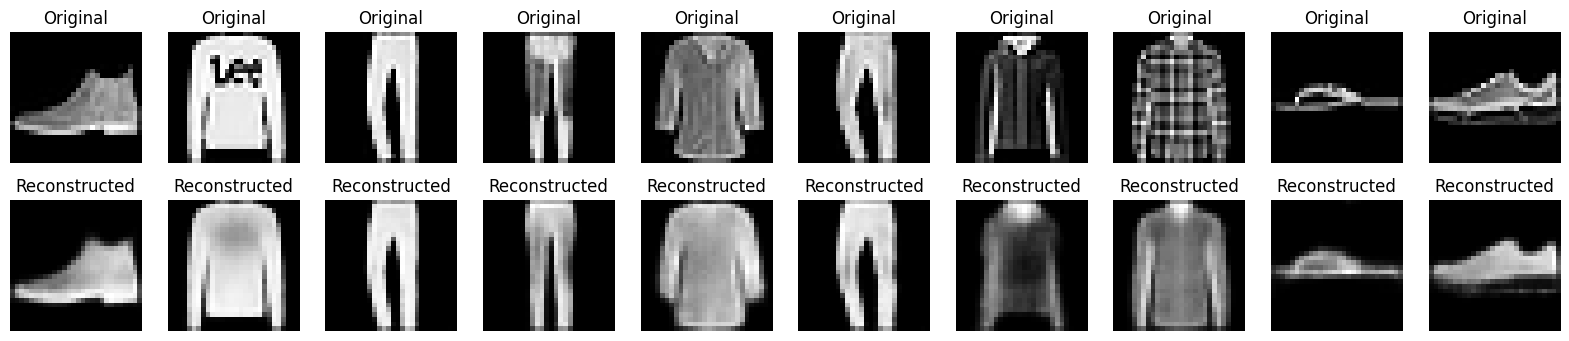

In [9]:
import matplotlib.pyplot as plt

generated_image = model.predict(x_test)


n = 10  # Number of clothing items to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Display Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(generated_image[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()